### Exercise Report for Course: Stochastic Simulation

0. Library Imports

In [124]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import geom
from scipy.stats.sampling import DiscreteAliasUrn
from scipy.stats import chisquare
import time
import random
import math

#### Day 1 Exercises

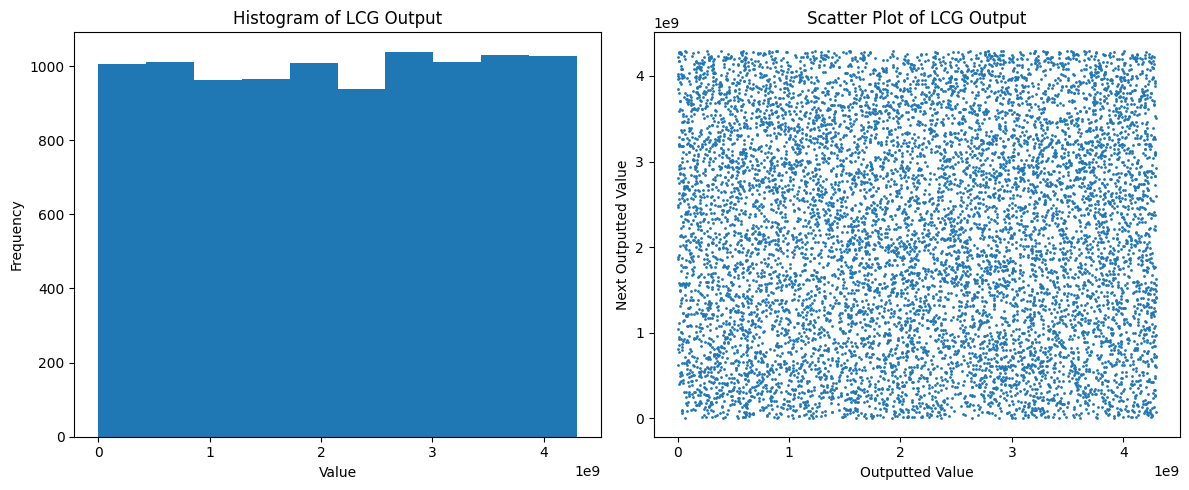

----- Chi-squared Test ------
Observed counts per bin: [1005. 1011.  964.  963. 1009.  940. 1039. 1013. 1030. 1026.]
Expected counts per bin: 1000.0
Chi-sq Statistic (T): 9.7580
Degrees of Freedom: 9
P-value: 0.370429
Fail to reject H0: The sequence follows a uniform distribution within the interval [0, 1].

----- Kolmogorov - Smirnov Test ------
D_n = 0.012506, n = 10000
Adjusted statistic = 1.252128, critical = 1.48
Fail to reject H0: sequence is consistent with uniformity.

----- Wald-Wolfowitz Run Test ------
Total elements (N): 10000 (n1=5000, n2=5000)
Observed Runs (T): 4976
Expected Runs (Mean): 5001.00
Standard Deviation: 49.9975
Z-statistic: -0.5000
P-value: 0.617057
Fail to reject H0: The sequence is consistent with randomness.

----- Autocorrelation (Serial Correlation) Test ------
Lag (h = 1 ):
  Sample Correlation Coefficient (r): -0.000057
  P-value: 0.995487
  Result: Fail to reject H0 - Consistent with independence.
---------------------------------------------
Lag (h =

In [211]:
# 1. Implementation of linear congruential generator (LCG)

def lcg(seed, a, c, m):
    """
    a = multiplier
    c = constant (or increment)
    m = modulus
    """
    return (a * seed + c) % m

# Generate an LCG sequence
def generate_lcg_sequence(seed, a, c, m, n):
    """
    Generates a sequence of numbers using the linear congruential generator (LCG) algorithm.
    """
    sequence = []
    for _ in range(n):
        seed = lcg(seed, a, c, m)
        sequence.append(seed)
    return sequence

# Parameter set that will satisfy the ull-Dobell Theorem
lcg_sequence = generate_lcg_sequence(42, 1664525, 1013904223, 2**32, 10000)

def plot_histogram(data, bins=10):
    plt.hist(data, bins=bins)
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.title('Histogram of LCG Output')


def graphical_lcg_check(seq):
    plt.scatter(seq[:-1], seq[1:], s=1)
    plt.xlabel('Outputted Value')
    plt.ylabel('Next Outputted Value')
    plt.title('Scatter Plot of LCG Output')


# Make 2 plots side by side to visually observe the distribution and independence
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plot_histogram(lcg_sequence)

plt.subplot(1, 2, 2)
graphical_lcg_check(lcg_sequence)

plt.tight_layout()
plt.show()


# Chi-squared test 
print("----- Chi-squared Test ------")

def chi_squared_test(sample, n_classes=10, m=2**32):
    N = len(sample)

    n_expected = N / n_classes
    # Check for the assumption (no less than 5 samples per group)
    if n_expected < 5:
        raise ValueError("Expected frequency is less than 5.")

    # Standardize the data before the test
    lcg_sequence_arr = np.array(sample)
    standardized_sequence = lcg_sequence_arr / m

    # Perform the Chi-squared test
    observed_counts = np.zeros(n_classes)

    for val in standardized_sequence:
        bin_idx = int(np.clip(val * n_classes, 0, n_classes - 1))
        observed_counts[bin_idx] += 1
        
    T = np.sum((observed_counts - n_expected)**2 / n_expected)


    df = n_classes - 1
    p_value = stats.chi2.sf(T, df)
    print(f"Observed counts per bin: {observed_counts}")
    print(f"Expected counts per bin: {n_expected}")
    print(f"Chi-sq Statistic (T): {T:.4f}")
    print(f"Degrees of Freedom: {df}")
    print(f"P-value: {p_value:.6f}")

    if p_value < 0.05:
        print("Reject H0: The sequence does not follow a uniform distribution.")
    else:
        print("Fail to reject H0: The sequence follows a uniform distribution within the interval [0, 1].")
    
    print("")
    return T, p_value

chi_squared_test(lcg_sequence)


# Apply Kolmogorov - Smirnov Test on the obtained sequence to see if it satisfies the condition

# Null Hypothesis: The LCG output is uniformly distributed
# Alternative Hypothesis: The LCG output is not uniformly distributed

def kolmogorov_dn(sample, cdf):
    x = np.sort(np.asarray(sample))
    n = x.size
    
    F_theoretical = x

    i = np.arange(1, n + 1)
    Fn_after = i / n
    Fn_before = (i - 1) / n

    diff_after = np.abs(Fn_after - F_theoretical)
    diff_before = np.abs(Fn_before - F_theoretical)
    
    # Take the absolute maximum difference found
    Dn = max(np.max(diff_after), np.max(diff_before))

    return Dn

print("----- Kolmogorov - Smirnov Test ------")

# Same as above the modulus value
m = 2**32         
arr = np.array(lcg_sequence)
u = arr / m

# Compute D_n
Dn = kolmogorov_dn(u, lambda z: z) 
n = u.size
print(f"D_n = {Dn:.6f}, n = {n}")

adjusted = (np.sqrt(n) + 0.12 + 0.11/np.sqrt(n)) * Dn
critical = 1.480 # from the provided critical value table from Day 1 slides

print(f"Adjusted statistic = {adjusted:.6f}, critical = {critical}")

if adjusted > critical:
    print("Reject H0: sequence is not uniform at this significance.")
else:
    print("Fail to reject H0: sequence is consistent with uniformity.")

# Run Test - Wald-Wolfowitz run test
def wald_wolfowitz_run_test(sample):
    print("\n----- Wald-Wolfowitz Run Test ------")
    median = np.median(sample)
    
    # Convert sequence to a binary sequence: True if > median, False if < median
    binary_seq = sample > median
    
    binary_seq = binary_seq[sample != median]
    
    # Count total elements above (n1) and below (n2) median
    n1 = np.sum(binary_seq)
    n2 = len(binary_seq) - n1
    
    # Calculate the actual number of runs (T)
    runs = 1 + np.sum(np.diff(binary_seq))
    
    # Theoretical Mean and Variance from your formula
    mean_T = (2 * n1 * n2) / (n1 + n2) + 1
    var_T = (2 * n1 * n2 * (2 * n1 * n2 - n1 - n2)) / (((n1 + n2)**2) * (n1 + n2 - 1))
    std_T = np.sqrt(var_T)
    
    # Z-score statistic
    Z = (runs - mean_T) / std_T
    
    # Two-tailed p-value
    p_value = 2 * stats.norm.sf(np.abs(Z))
    
    print(f"Total elements (N): {n1 + n2} (n1={n1}, n2={n2})")
    print(f"Observed Runs (T): {runs}")
    print(f"Expected Runs (Mean): {mean_T:.2f}")
    print(f"Standard Deviation: {std_T:.4f}")
    print(f"Z-statistic: {Z:.4f}")
    print(f"P-value: {p_value:.6f}")
    
    if p_value < 0.05:
        print("Reject H0: The sequence is not random (non-independent).")
    else:
        print("Fail to reject H0: The sequence is consistent with randomness.")
        
    return runs, p_value

runs, p_val_wald = wald_wolfowitz_run_test(lcg_sequence)


# Autocorrelation test
def autocorrelation_test(sample, lags=[1, 2, 3, 5, 10], m=2**32):
    """
    Tests for serial correlation within the LCG sequence at various lag (h) values.
    Null Hypothesis (H0): The sequence numbers are independent (autocorrelation = 0).
    """
    print("\n----- Autocorrelation (Serial Correlation) Test ------")
    
    # Standardize data to [0, 1] matching your prior test methods
    u = np.array(sample) / m
    N = len(u)
    
    results = []
    
    for h in lags:
        # Create shifted arrays to check alignment at lag h
        # x is the sequence elements, y is the sequence elements h steps ahead
        x = u[:-h]
        y = u[h:]
        
        # Calculate Pearson correlation coefficient (r) and its two-tailed p-value
        r_h, p_value = stats.pearsonr(x, y)
        
        print(f"Lag (h = {h:<2}):")
        print(f"  Sample Correlation Coefficient (r): {r_h:.6f}")
        print(f"  P-value: {p_value:.6f}")
        
        if p_value < 0.05:
            print("  Result: Reject H0 - Significant correlation detected.")
            status = "Rejected (Non-random)"
        else:
            print("  Result: Fail to reject H0 - Consistent with independence.")
            status = "Fail to Reject (Independent)"
        print("-" * 45)
        
        results.append({
            "Lag (h)": h,
            "Correlation (r)": r_h,
            "P-value": p_value,
            "H0 Status": status
        })
        
    return pd.DataFrame(results)

# Run the autocorrelation check for your custom h-values
acf_df = autocorrelation_test(lcg_sequence, lags=[1, 2, 3, 4, 5, 10, 50])


### Day 1: Test different parameter values

 TESTING PARAMETERS: 1st Bad Choice
 a = 65539, c = 0, m = 2147483648


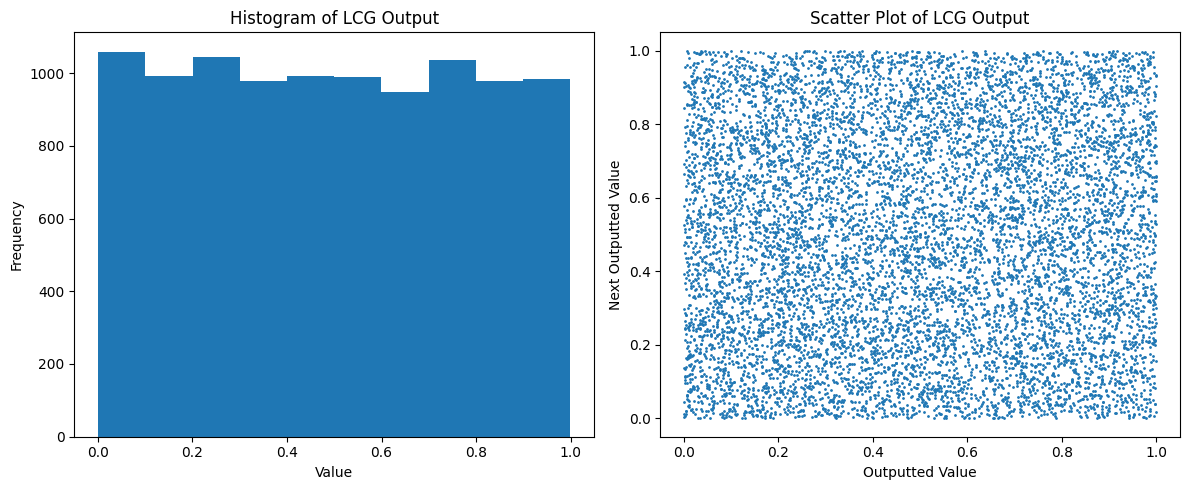

Observed counts per bin: [1059.  991. 1045.  979.  991.  990.  952. 1033.  977.  983.]
Expected counts per bin: 1000.0
Chi-sq Statistic (T): 10.4200
Degrees of Freedom: 9
P-value: 0.317565
Fail to reject H0: The sequence follows a uniform distribution within the interval [0, 1].

KS Test: Adjusted = 1.1449 (Critical = 1.48)
Result: Fail to reject H0 (Uniform)

----- Wald-Wolfowitz Run Test ------
Total elements (N): 10000 (n1=5000, n2=5000)
Observed Runs (T): 4900
Expected Runs (Mean): 5001.00
Standard Deviation: 49.9975
Z-statistic: -2.0201
P-value: 0.043373
Reject H0: The sequence is not random (non-independent).


 TESTING PARAMETERS: 2nd Bad Choice
 a = 5, c = 3, m = 1024


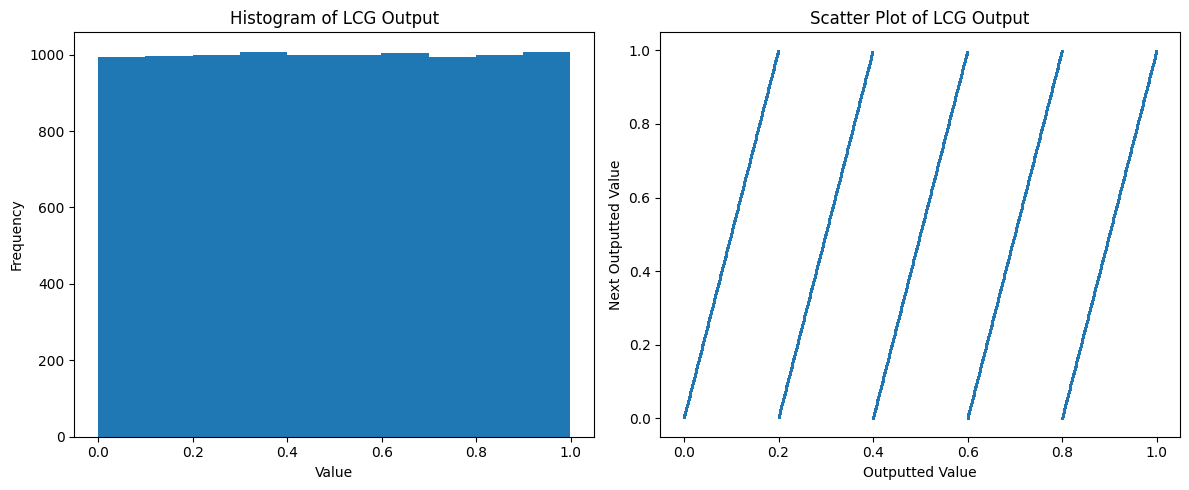

Observed counts per bin: [ 995.  996. 1009.  998.  999. 1009.  994. 1003.  998.  999.]
Expected counts per bin: 1000.0
Chi-sq Statistic (T): 0.2580
Degrees of Freedom: 9
P-value: 0.999998
Fail to reject H0: The sequence follows a uniform distribution within the interval [0, 1].

KS Test: Adjusted = 0.1466 (Critical = 1.48)
Result: Fail to reject H0 (Uniform)

----- Wald-Wolfowitz Run Test ------
Total elements (N): 9991 (n1=4994, n2=4997)
Observed Runs (T): 4005
Expected Runs (Mean): 4996.50
Standard Deviation: 49.9750
Z-statistic: -19.8399
P-value: 0.000000
Reject H0: The sequence is not random (non-independent).


 TESTING PARAMETERS: Final Choice
 a = 1664525, c = 1013904223, m = 4294967296


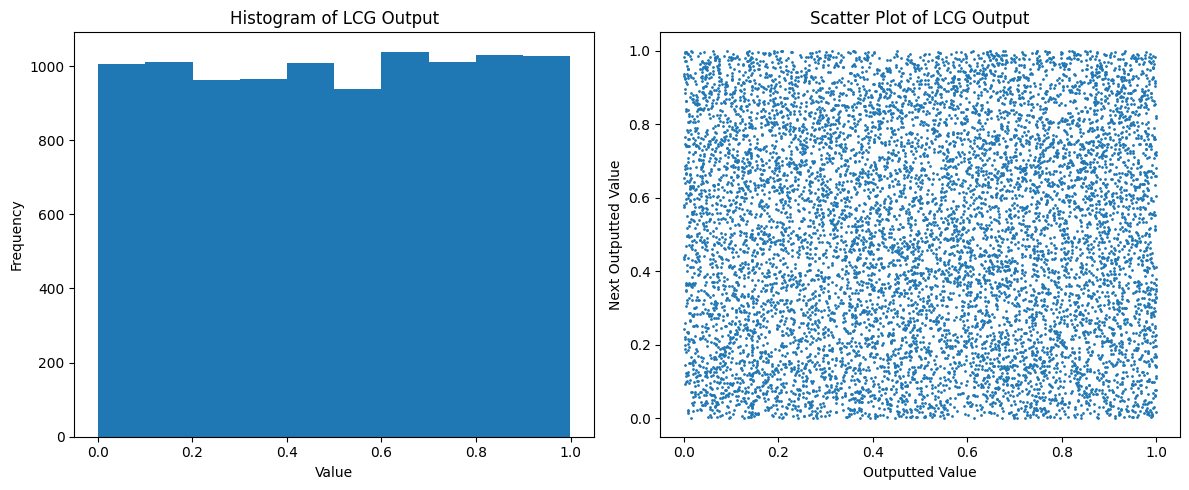

Observed counts per bin: [1005. 1011.  964.  963. 1009.  940. 1039. 1013. 1030. 1026.]
Expected counts per bin: 1000.0
Chi-sq Statistic (T): 9.7580
Degrees of Freedom: 9
P-value: 0.370429
Fail to reject H0: The sequence follows a uniform distribution within the interval [0, 1].

KS Test: Adjusted = 1.2521 (Critical = 1.48)
Result: Fail to reject H0 (Uniform)

----- Wald-Wolfowitz Run Test ------
Total elements (N): 10000 (n1=5000, n2=5000)
Observed Runs (T): 4976
Expected Runs (Mean): 5001.00
Standard Deviation: 49.9975
Z-statistic: -0.5000
P-value: 0.617057
Fail to reject H0: The sequence is consistent with randomness.




In [126]:

experiments = [
    # 1. Badly configured generator
    (65539, 0, 2**31, "1st Bad Choice"),
    
    # 2. Another poorly configured custom setup
    (5, 3, 1024, "2nd Bad Choice"),
    
    # 3. Final best choice that we agreed on with the Team
    (1664525, 1013904223, 2**32, "Final Choice")
]

# Run the analysis for each setup
for a_val, c_val, m_val, label in experiments:
    print("==================================================")
    print(f" TESTING PARAMETERS: {label}")
    print(f" a = {a_val}, c = {c_val}, m = {m_val}")
    print("==================================================")
    
    # Generate sequence
    seq = generate_lcg_sequence(seed=42, a=a_val, c=c_val, m=m_val, n=10000)
    
    # Compute a clean standardized array for the statistical checks
    seq_arr = np.array(seq)
    u_scaled = seq_arr / m_val
    
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plot_histogram(u_scaled)

    plt.subplot(1, 2, 2)
    graphical_lcg_check(u_scaled)

    plt.tight_layout()
    plt.show()

    
    # Chi-Squared Test
    _ = chi_squared_test(seq, n_classes=10, m=m_val)
    
    # KS Test
    Dn_val = kolmogorov_dn(u_scaled, lambda z: z)
    n_samples = u_scaled.size
    adjusted_stat = (np.sqrt(n_samples) + 0.12 + 0.11/np.sqrt(n_samples)) * Dn_val
    critical_val = 1.480
    print(f"KS Test: Adjusted = {adjusted_stat:.4f} (Critical = {critical_val})")
    if adjusted_stat > critical_val:
        print("Result: Reject H0 (Non-uniform)")
    else:
        print("Result: Fail to reject H0 (Uniform)")
        
    # Wald-Wolfowitz Run Test
    _, _ = wald_wolfowitz_run_test(seq_arr)
    print("\n")

### Day 1: apply a system-available generator

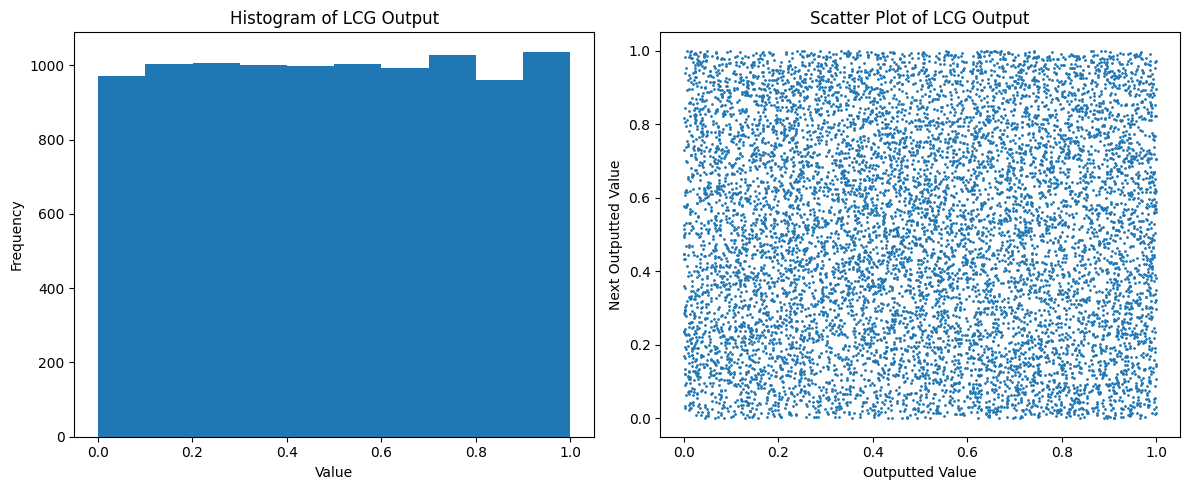

Observed counts per bin: [1005. 1011.  964.  963. 1009.  940. 1039. 1013. 1030. 1026.]
Expected counts per bin: 1000.0
Chi-sq Statistic (T): 9.7580
Degrees of Freedom: 9
P-value: 0.370429
Fail to reject H0: The sequence follows a uniform distribution within the interval [0, 1].

KS Test: Adjusted = 1.2521 (Critical = 1.48)
Result: Fail to reject H0 (Uniform)

----- Wald-Wolfowitz Run Test ------
Total elements (N): 10000 (n1=5000, n2=5000)
Observed Runs (T): 4976
Expected Runs (Mean): 5001.00
Standard Deviation: 49.9975
Z-statistic: -0.5000
P-value: 0.617057
Fail to reject H0: The sequence is consistent with randomness.


In [127]:
system_sequence = np.random.uniform(low=0.0, high=1.0, size=10000)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plot_histogram(system_sequence)


plt.subplot(1, 2, 2)
graphical_lcg_check(system_sequence)

plt.tight_layout()
plt.show()

# Run tests
# Chi-Squared Test
_ = chi_squared_test(seq, n_classes=10, m=m_val)

# KS Test
Dn_val = kolmogorov_dn(u_scaled, lambda z: z)
n_samples = u_scaled.size
adjusted_stat = (np.sqrt(n_samples) + 0.12 + 0.11/np.sqrt(n_samples)) * Dn_val
critical_val = 1.480
print(f"KS Test: Adjusted = {adjusted_stat:.4f} (Critical = {critical_val})")
if adjusted_stat > critical_val:
    print("Result: Reject H0 (Non-uniform)")
else:
    print("Result: Fail to reject H0 (Uniform)")
    
# Wald-Wolfowitz Run Test
_, _ = wald_wolfowitz_run_test(seq_arr)


### Last part of day 1: 'You were asked to simulate one sample and perform tests on this sample. Discuss the suﬃciency of this approach and take action, if needed.'

My response: No, it is not sufficient to simulate only one sample and perform tests on this sample alone. Even if a sample would contain 1 000 000 numbers in it, it would still count as a unique realization in a random process. To fix that, we could run multiple independent samples, that are instantiated with various seed values, store the results and analyse the statistics of those results.


#### Action: macro repetition study to simulate the sequence and tests


----- Macro-Repetition Study (100 Independent Runs) -----


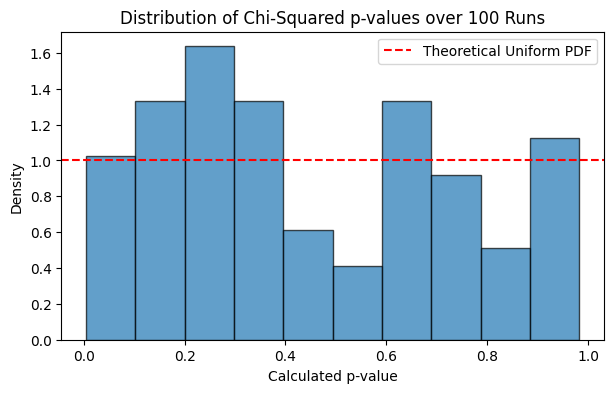

Total simulations run: 100
Number of times H0 was rejected (p < 0.05): 3
Observed Type I Error Rate: 3.00%


In [128]:
def macro_repetition_study(a, c, m, num_macro_reps=100, sample_size=10000):
    print(f"\n----- Macro-Repetition Study ({num_macro_reps} Independent Runs) -----")
    
    chi2_p_values = []
    
    # Use a base seed, changing it slightly for each macro-repetition
    base_seed = 42
    
    for i in range(num_macro_reps):
        current_seed = base_seed + i
        
        # Generate sequence using the best set of parameters we agreed on in the team
        seq = generate_lcg_sequence(seed=current_seed, a=a, c=c, m=m, n=sample_size)
        
        # Extract the p-value 
        seq_arr = np.array(seq)
        standardized_sequence = seq_arr / m
        
        n_classes = 10
        n_expected = sample_size / n_classes
        observed_counts = np.zeros(n_classes)
        
        for val in standardized_sequence:
            bin_idx = int(np.clip(val * n_classes, 0, n_classes - 1))
            observed_counts[bin_idx] += 1
            
        T = np.sum((observed_counts - n_expected)**2 / n_expected)
        p_val = stats.chi2.sf(T, n_classes - 1)
        
        chi2_p_values.append(p_val)
        
    # Graphical Check of the p-values
    plt.figure(figsize=(7, 4))
    plt.hist(chi2_p_values, bins=10, edgecolor='black', alpha=0.7, density=True)
    plt.axhline(y=1.0, color='r', linestyle='--', label='Theoretical Uniform PDF')
    plt.xlabel('Calculated p-value')
    plt.ylabel('Density')
    plt.title('Distribution of Chi-Squared p-values over 100 Runs')
    plt.legend()
    plt.show()
    
    # Count how many times we rejected H0 out of the 100 runs
    rejections = np.sum(np.array(chi2_p_values) < 0.05)
    print(f"Total simulations run: {num_macro_reps}")
    print(f"Number of times H0 was rejected (p < 0.05): {rejections}")
    print(f"Observed Type I Error Rate: {rejections / num_macro_reps:.2%}")

# Run the macro study on the final choice parameters
macro_repetition_study(a=1664525, c=1013904223, m=2**32)